In [12]:
import sympy as sp
import networkx as nx
import numpy as np
import json

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tqdm

import linearframework.gen_graphs as gen
from linearframework.linear_framework_graph import LinearFrameworkGraph, hill_augmented_graph

testing the hopfield barrier in splitting probability. just preliminarily.

Unlike sympy, numpy does not have a builtin method for taking the minors of a matrix.

In [5]:
def matrix_minor(arr, i, j):
    return np.delete(np.delete(arr,i,axis=0), j, axis=1)

In [6]:
# defining the graph:
alpha = 5
k = 3
num_samples = 1000

butterfly_t_eq_etw = gen.gen_core_butterfly_dict(alpha, k, tails = True)

def calc_epsilon_sp(terminal_butterfly_edge_to_weight, k):

    terminal_butterfly = LinearFrameworkGraph(terminal_butterfly_edge_to_weight)
    hill_butterfly = hill_augmented_graph(terminal_butterfly, '1')

    index_pk = hill_butterfly.nodes.index(f'p_{k}')
    correct_sp = np.linalg.det(matrix_minor(hill_butterfly.Lap, index_pk, index_pk))

    index_pbk = hill_butterfly.nodes.index(f'p_bar_{k}')
    incorrect_sp = np.linalg.det(matrix_minor(hill_butterfly.Lap, index_pbk, index_pbk))

    return incorrect_sp / correct_sp

calc_epsilon_sp(butterfly_t_eq_etw, k)


0.20010738728160582

In [ ]:
def epsilon_sp_monte_carlo(k, alphas, num_samples):

    eq_datapoints_by_alpha = {}
    neq_datapoints_by_alpha = {}

    for alpha in tqdm.tqdm(alphas):
        eq_datapoints = []
        neq_datapoints = []

        for i in range(num_samples):
            butterfly_t_eq_etw = gen.gen_core_butterfly_dict(alpha, k, tails = True)
            eq_datapoints.append(calc_epsilon_sp(butterfly_t_eq_etw, k))

            butterfly_t_neq_etw = gen.gen_core_butterfly_dict(alpha, k, equilibrium=False, tails=True)
            neq_datapoints.append(calc_epsilon_sp(butterfly_t_neq_etw, k))
        
        eq_datapoints_by_alpha[alpha] = eq_datapoints
        neq_datapoints_by_alpha[alpha] = neq_datapoints
    
    return eq_datapoints_by_alpha, neq_datapoints_by_alpha

k = 2
num_samples = 1000
num_alphas = 100
max_alpha = 10

alphas = np.arange(1, max_alpha, (max_alpha - 1)/num_alphas)

eq_datapoints_by_alpha, neq_datapoints_by_alpha = epsilon_sp_monte_carlo(k, alphas, num_samples)

100%|██████████| 100/100 [00:13<00:00,  7.54it/s]


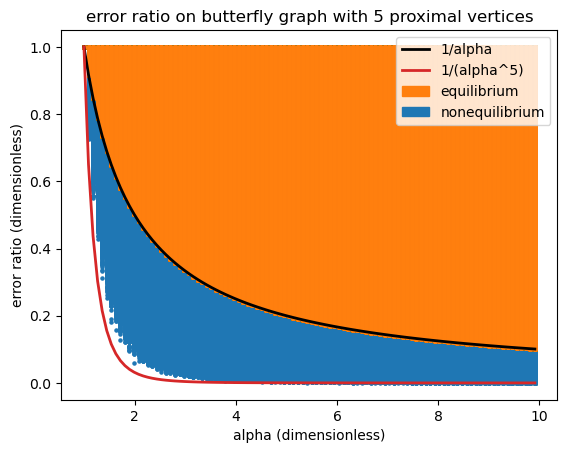

In [ ]:
def plot_epsilon_sp_monte_carlo(eq_datapoints_by_alpha, neq_datapoints_by_alpha, k, alphas, num_samples, save=False):
    for alpha in alphas:
        plt.scatter(alpha * np.ones(num_samples), neq_datapoints_by_alpha[alpha], color='tab:blue', s=5)
        plt.scatter(alpha * np.ones(num_samples), eq_datapoints_by_alpha[alpha], color='tab:orange', s=5)


    plt.plot(alphas, 1/alphas, color='black', label='1/alpha', linewidth=2)
    plt.plot(alphas, 1/(alphas ** k), color='tab:red', label=f'1/(alpha^{k})', linewidth=2)

    equilibrium_patch = mpatches.Patch(color='tab:orange', label='equilibrium')
    # plt.legend(handles=[equilibrium_patch])

    non_equilibrium_patch = mpatches.Patch(color='tab:blue', label='nonequilibrium')
    # plt.legend(handles=[non_equilibrium_patch])

    handles, labels = plt.gca().get_legend_handles_labels()
    handles.extend([equilibrium_patch, non_equilibrium_patch])

    plt.xlabel('alpha (dimensionless)')
    plt.ylabel("error ratio (dimensionless)")

    plt.title(f'error ratio on butterfly graph with {k} proximal vertices')
    plt.legend(loc='upper right', handles=handles)

    if save:
        filepath = f'splitting-probability-error-ratio/epsilon_sp_k{k}_butterfly.png'
        
        plt.savefig(filepath, format='png')
        print(f'plot saved as {filepath}')

        plt.clf()
        
    else:
        plt.show()


plot_epsilon_sp_monte_carlo(eq_datapoints_by_alpha, neq_datapoints_by_alpha, k, alphas, num_samples, save=False)

In [ ]:
ks = [3, 5, 7, 9]

num_samples = 100000
num_alphas = 150
max_alpha = 10
alphas = np.arange(1, max_alpha, (max_alpha - 1)/num_alphas)

datapoints = {}

for k in ks:
    print(f'generating epsilon_sp samples for k={k} terminal butterfly graph . . .')
    eq_datapoints_by_alpha, neq_datapoints_by_alpha = epsilon_sp_monte_carlo(k, alphas, num_samples)

    datapoints[k] = (eq_datapoints_by_alpha, neq_datapoints_by_alpha)

    # print('plotting figure . . .')
    # plot_epsilon_sp_monte_carlo(eq_datapoints_by_alpha, neq_datapoints_by_alpha, k, alphas, num_samples, save=True)

# out_file = open("splitting-probability-error-ratio/epsion_sp-datapoints.json", "w")  
    
# json.dump(datapoints, out_file, indent = 6)  
    
# out_file.close()  

generating epsilon_sp samples for k=3 terminal butterfly graph . . .


100%|██████████| 150/150 [1:52:08<00:00, 44.86s/it]   


generating epsilon_sp samples for k=5 terminal butterfly graph . . .


100%|██████████| 150/150 [3:36:28<00:00, 86.59s/it]   


generating epsilon_sp samples for k=7 terminal butterfly graph . . .


100%|██████████| 150/150 [3:15:20<00:00, 78.14s/it]   


generating epsilon_sp samples for k=9 terminal butterfly graph . . .


100%|██████████| 150/150 [3:39:39<00:00, 87.86s/it]   


In [ ]:
k = 5
num_samples = 100000
num_alphas = 100
max_alpha = 10
alphas = np.arange(1, max_alpha, (max_alpha - 1)/num_alphas)

print(f'generating epsilon_sp samples for k={k} terminal butterfly graph . . .')
eq_datapoints_by_alpha, neq_datapoints_by_alpha = epsilon_sp_monte_carlo(k, alphas, num_samples)

datapoints[k] = (eq_datapoints_by_alpha, neq_datapoints_by_alpha)

generating epsilon_sp samples for k=5 terminal butterfly graph . . .


100%|██████████| 100/100 [3:19:27<00:00, 119.67s/it] 


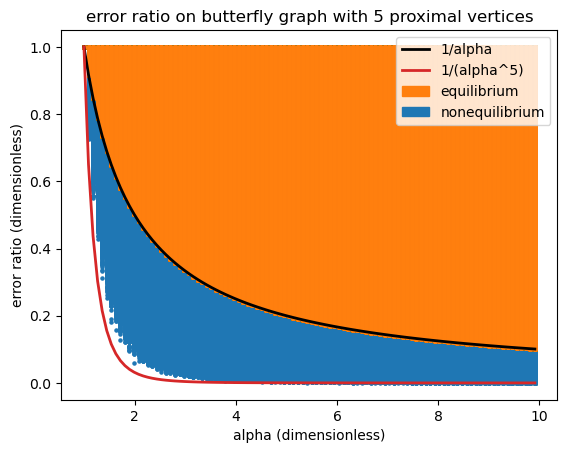

In [23]:
plot_epsilon_sp_monte_carlo(eq_datapoints_by_alpha, neq_datapoints_by_alpha, k, alphas, num_samples, save=False)

In [33]:
# for k in ks:
k = 9
num_alphas = 150
num_samples = 100000
alphas = np.arange(1, max_alpha, (max_alpha - 1)/num_alphas)
print(f'generating epsilon_sp samples for k={k} terminal butterfly graph . . .')
# eq_datapoints_by_alpha, neq_datapoints_by_alpha = epsilon_sp_monte_carlo(k, alphas, num_samples)

# datapoints[k] = (eq_datapoints_by_alpha, neq_datapoints_by_alpha)

eq_datapoints_by_alpha, neq_datapoints_by_alpha = datapoints[k]

print('plotting figure . . .')
plot_epsilon_sp_monte_carlo(eq_datapoints_by_alpha, neq_datapoints_by_alpha, k, alphas, num_samples, save=True)


generating epsilon_sp samples for k=9 terminal butterfly graph . . .
plotting figure . . .
plot saved as splitting-probability-error-ratio/epsilon_sp_k9_butterfly.png


<Figure size 640x480 with 0 Axes>